# 2. Ecosystem Transition - Biomass Change Analysis

In [1]:
import rasterio
import numpy as np
from rasterio.plot import show
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [2]:
# --- INPUT FILES ---
#transition_file = "data/iplant/home/shared/earthlab/NC_eco_transformations/Transformations/Transformed_areas/trans_nc_USA/trans_NA.tif"     # single-band: year of transition
#transition_file = "home/emulder/NE_trans.tif"
#transition_file = "WY_trans.tif"
#biomass_file = "bm_clip_resampled_bilinear_multiBand_WY.tif"      # 15-band raster
#output_file = "biomass_pre_post_transition_WY.tif"
transition_file = "/data-store/iplant/home/shared/earthlab/NC_eco_transformations/BM_analysis/WY/BM_analysis/WY_trans.tif"
biomass_file = "/data-store/iplant/home/shared/earthlab/NC_eco_transformations/BM_analysis/WY/BM_analysis/bm_clip_resampled_bilinear_multiBand_WY.tif"      # 15-band raster
output_file = "biomass_pre_post_transition_WY_updated.tif"

In [3]:
# --- READ INPUTS ---
with rasterio.open(transition_file) as trans_src, rasterio.open(biomass_file) as bio_src:
    transition = trans_src.read(1)
    biomass = bio_src.read()  # shape: (15, H, W)
    meta = bio_src.meta.copy()

In [4]:
# --- DEFINE BIOMASS YEARS ---
biomass_years = np.arange(2003, 2018)  # 15 years

In [5]:
# Convert transition "offsets" to full years
#transition = 2000 + transition  # adjust base year if needed
transition = transition.astype(np.int32)

/tmp/ipykernel_395/3338067843.py:3: RuntimeWarning: invalid value encountered in cast
  transition = transition.astype(np.int32)


In [6]:
print(np.unique(transition))

[-2147483648           0        1985        1986        1987        1988
        1989        1990        1991        1992        1993        1994
        1995        1996        1997        1998        1999        2000
        2001        2002        2003        2004        2005        2006
        2007        2008        2009        2010        2011]


In [7]:
transition_years = np.arange(2003, 2012)
print(transition_years)

[2003 2004 2005 2006 2007 2008 2009 2010 2011]


In [8]:
if trans_src.crs != bio_src.crs:
    raise ValueError(f"CRS mismatch: transition={trans_src.crs}, biomass={bio_src.crs}")
else:
    print("CRS match confirmed:", trans_src.crs)

CRS match confirmed: EPSG:4326


In [9]:
# --- PREPARE OUTPUT ARRAYS ---
pre_mean = np.full_like(transition, 0, dtype="float32")
post_mean = np.full_like(transition, 0, dtype="float32")
pre_var   = np.full_like(transition, 0, dtype="float32")
post_var  = np.full_like(transition, 0, dtype="float32")

In [10]:
# --- Main computation ---
for y in np.unique(transition):
    if np.isnan(y) or y <= 0:
        continue
    mask = transition == y

    if y < biomass_years.min() or y > biomass_years.max():
        continue

    #pre_mask = biomass_years < y
    #post_mask = biomass_years > y

    # --- Pre-transition mask: ONLY the 3 years before y ---
    pre_window_start = y - 3
    pre_window_end = y - 1
    pre_mask = (biomass_years >= pre_window_start) & (biomass_years <= pre_window_end)

    # --- Post-transition mask: ONLY the most recent 3 years (2015–2017) ---
    post_mask = (biomass_years >= 2015) & (biomass_years <= 2017)

    # Pre years
    if np.any(pre_mask):
        pre_vals = biomass[pre_mask, :, :]
        pre_mean_arr = pre_vals.mean(axis=0)
        pre_var_arr = pre_vals.var(axis=0)
        pre_mean[mask] = pre_mean_arr[mask]
        pre_var[mask] = pre_var_arr[mask]

    # Post years
    if np.any(post_mask):
        post_vals = biomass[post_mask, :, :]
        post_mean_arr = post_vals.mean(axis=0)
        post_var_arr = post_vals.var(axis=0)
        post_mean[mask] = post_mean_arr[mask]
        post_var[mask] = post_var_arr[mask]

# --- Biomass change (Post - Pre) ---
biomass_change = post_mean - pre_mean

# Combined standard deviation
combined_std = np.sqrt(pre_var + post_var)

# Significance mask: 1 = outside variance, 0 = inside ---
significance_mask = np.zeros_like(biomass_change, dtype="float32")
significance_mask[np.abs(biomass_change) > combined_std] = 1
significance_mask[np.isnan(biomass_change)] = np.nan

# Filtered biomass change (only outside variance) ---
change_outside_var = np.where(significance_mask == 1, biomass_change, np.nan)

# Final layer: year of transition for each pixel
transition_year_layer = transition.astype("float32")

In [11]:
# --- HANDLE NODATA (OPTIONAL) ---
nodata = -9999
pre_mean = np.where(np.isnan(pre_mean), nodata, pre_mean)
post_mean = np.where(np.isnan(post_mean), nodata, post_mean)

In [12]:
# --- UPDATE METADATA (PRESERVE PROJECTION + GRID) ---
meta.update({
    "count": 8,
    "dtype": "float32",
    "nodata": nodata,
    "crs": bio_src.crs,
    "transform": bio_src.transform,
    "width": bio_src.width,
    "height": bio_src.height
})

In [13]:
# --- WRITE OUTPUT ---
with rasterio.open(output_file, "w", **meta) as dst:
    dst.write(np.nan_to_num(pre_mean, nan=nodata), 1)
    dst.write(np.nan_to_num(post_mean, nan=nodata), 2)
    dst.write(np.nan_to_num(pre_var, nan=nodata), 3)
    dst.write(np.nan_to_num(post_var, nan=nodata), 4)
    dst.write(np.nan_to_num(biomass_change, nan=nodata), 5)
    dst.write(np.nan_to_num(significance_mask, nan=nodata), 6)
    dst.write(np.nan_to_num(change_outside_var, nan=nodata), 7)
    dst.write(np.nan_to_num(transition_year_layer, nan=nodata), 8)
print(f"Output saved: {output_file}")


Output saved: biomass_pre_post_transition_WY_updated.tif


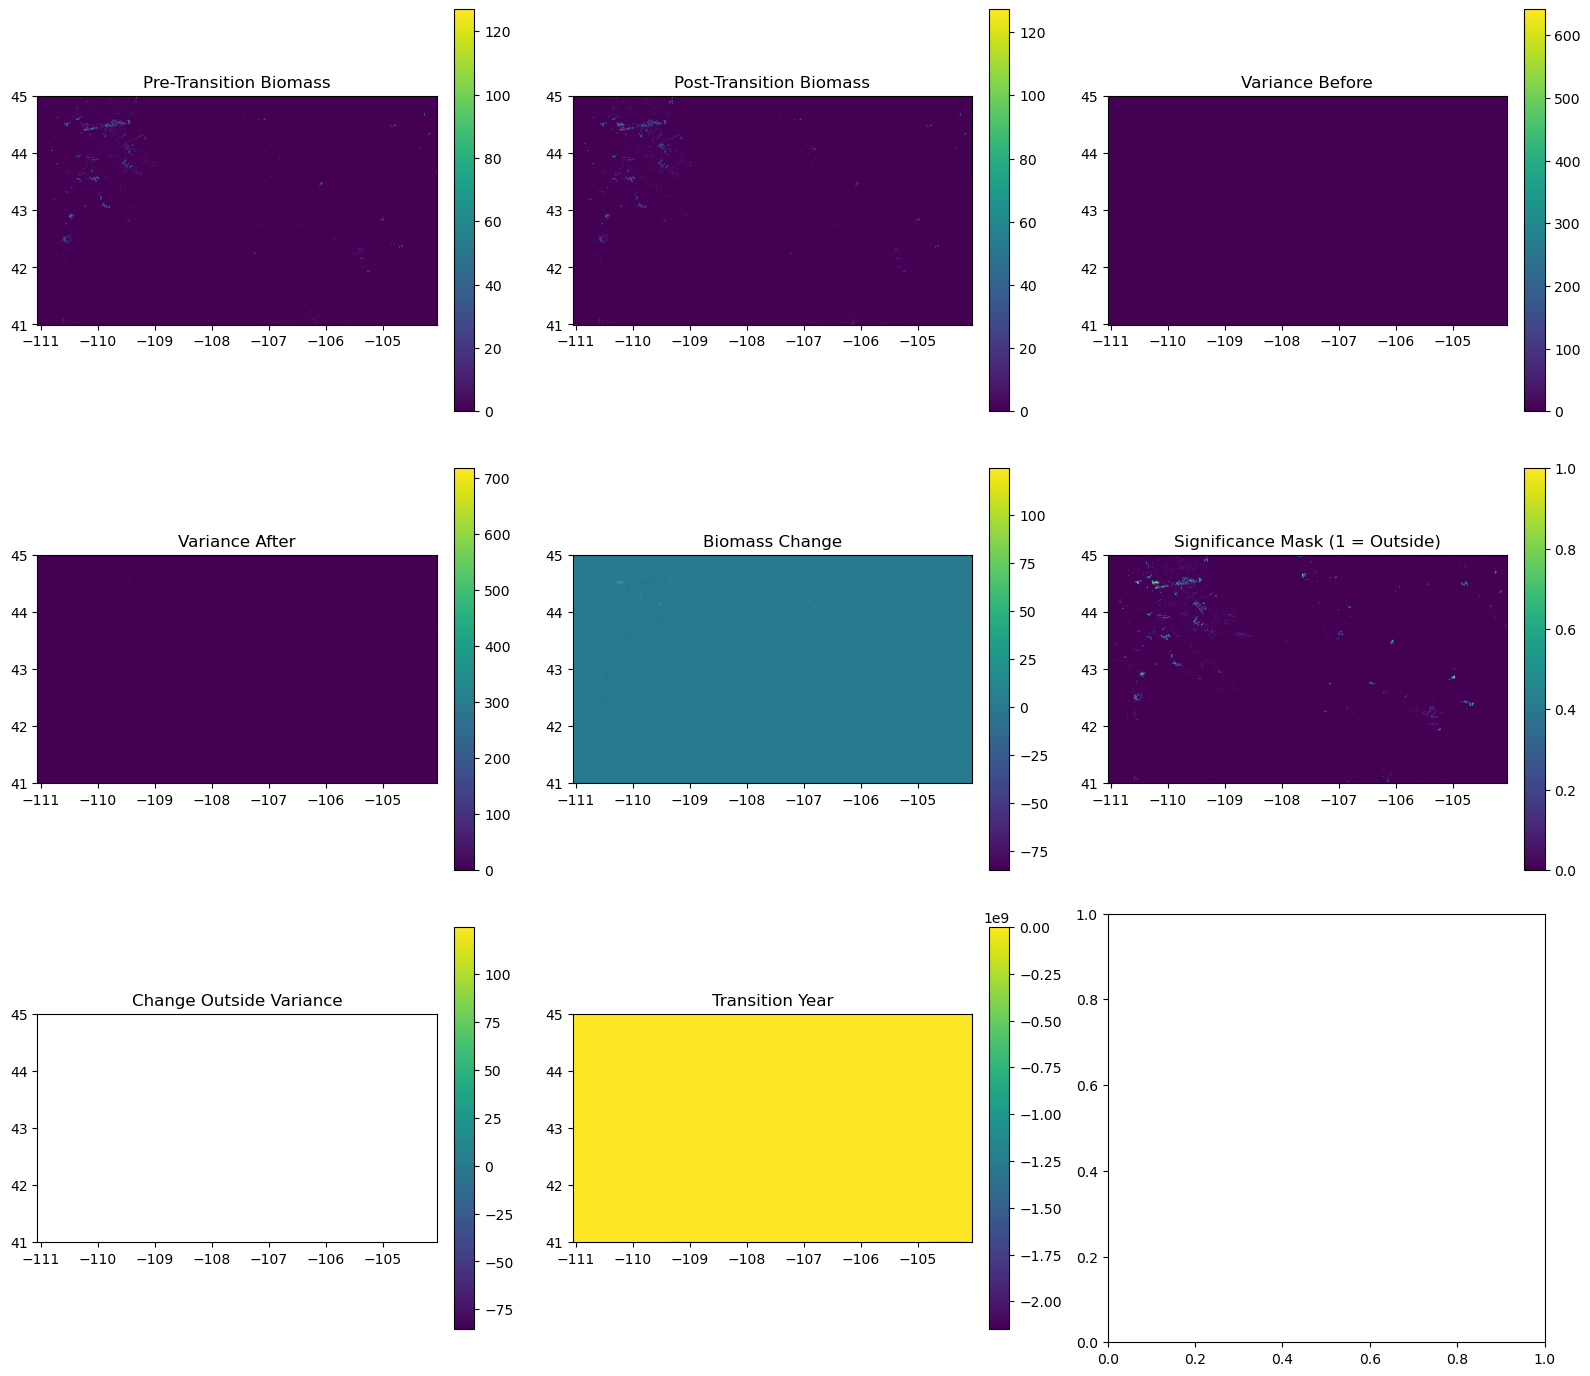

In [14]:
with rasterio.open(output_file) as src:
    data = src.read(masked=True)
    extent = rasterio.plot.plotting_extent(src)

titles = [
    "Pre-Transition Biomass",
    "Post-Transition Biomass",
    "Variance Before",
    "Variance After",
    "Biomass Change",
    "Significance Mask (1 = Outside)",
    "Change Outside Variance",
    "Transition Year"
]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
for i, ax in enumerate(axes.flat[:8]):
    im = ax.imshow(data[i], cmap='viridis', extent=extent)
    ax.set_title(titles[i])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

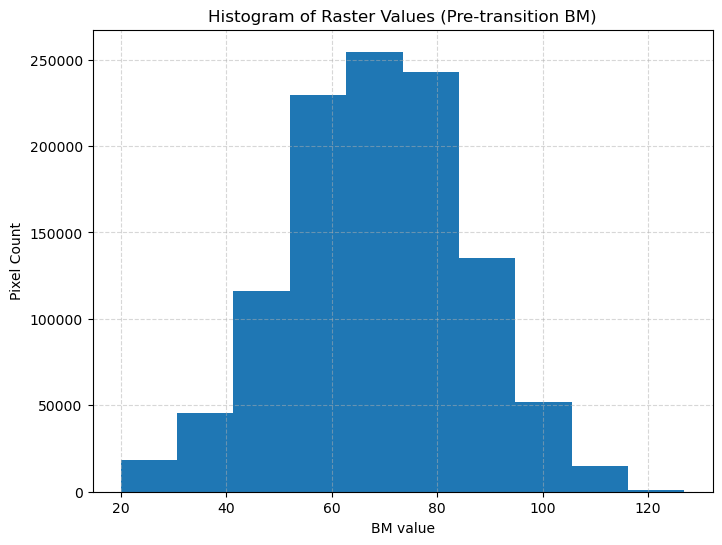

In [18]:
with rasterio.open(output_file) as src:
    # Read the first band (or change to another if needed)
    data = src.read(1)
    nodata = src.nodata

data_filtered = data[(data > 20)] #& (data <= 2017)]
# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(data_filtered)#, bins=np.arange(1980, 2018, 1), color='steelblue', edgecolor='black')
plt.title("Histogram of Raster Values (Pre-transition BM)")
plt.xlabel("BM value")
plt.ylabel("Pixel Count")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

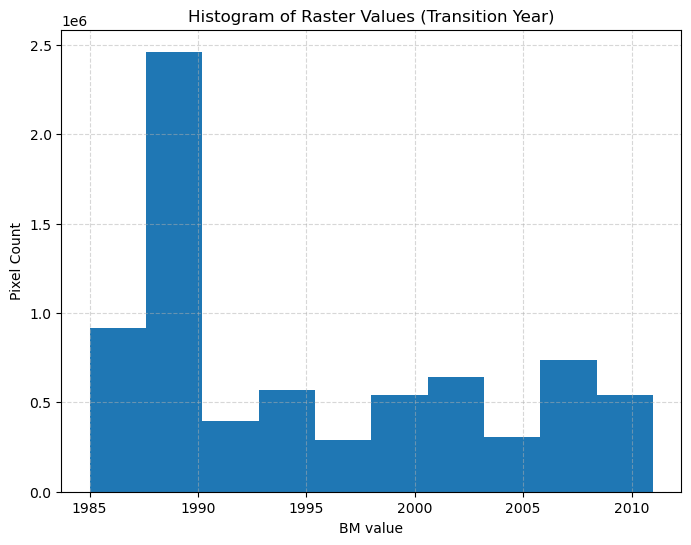

In [22]:
with rasterio.open(output_file) as src:
    # Read the first band (or change to another if needed)
    data = src.read(8)
    nodata = src.nodata

data_filtered = data[(data > 0)] #& (data <= 2017)]
# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(data_filtered)#, bins=np.arange(1980, 2018, 1), color='steelblue', edgecolor='black')
plt.title("Histogram of Raster Values (Transition Year)")
plt.xlabel("BM value")
plt.ylabel("Pixel Count")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

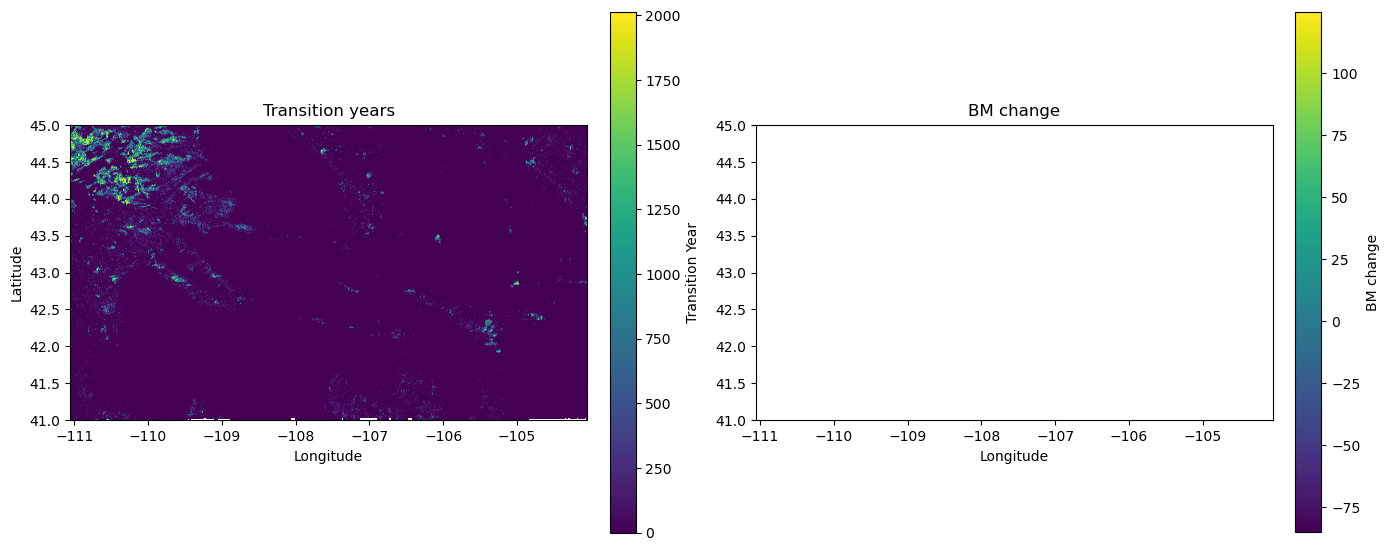

In [16]:
with rasterio.open(output_file) as src:
    BM_change = src.read(7, masked=True) # read BM change band
    extent = rasterio.plot.plotting_extent(src)
    crs = src.crs
with rasterio.open(transition_file) as src:
    trans = src.read(1)  # read first band
    extent = rasterio.plot.plotting_extent(src)
    crs = src.crs

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

img1 = ax1.imshow(trans, cmap='viridis', extent=extent)
ax1.set_title("Transition years")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
fig.colorbar(img1, ax=ax1, fraction=0.046, pad=0.04, label='Transition Year')

img2 = ax2.imshow(BM_change, cmap='viridis', extent=extent)
ax2.set_title("BM change")
ax2.set_xlabel("Longitude")
fig.colorbar(img2, ax=ax2, fraction=0.046, pad=0.04, label='BM change')

plt.tight_layout()
plt.show()

In [17]:
    print("Transition shape:", transition.shape)
    print("Biomass shape:", biomass.shape)
    print("Transition CRS:", trans_src.crs)
    print("Biomass CRS:", bio_src.crs)
    print("Transition transform:", trans_src.transform)
    print("Biomass transform:", bio_src.transform)
    print("Transition years (unique):", np.unique(transition[~np.isnan(transition)]))
    print("Biomass years:", np.arange(2003, 2018))

Transition shape: (14882, 25984)
Biomass shape: (15, 14882, 25984)
Transition CRS: EPSG:4326
Biomass CRS: EPSG:4326
Transition transform: | 0.00, 0.00,-111.05|
| 0.00,-0.00, 45.01|
| 0.00, 0.00, 1.00|
Biomass transform: | 0.00, 0.00,-111.05|
| 0.00,-0.00, 45.01|
| 0.00, 0.00, 1.00|
Transition years (unique): [-2147483648           0        1985        1986        1987        1988
        1989        1990        1991        1992        1993        1994
        1995        1996        1997        1998        1999        2000
        2001        2002        2003        2004        2005        2006
        2007        2008        2009        2010        2011]
Biomass years: [2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016
 2017]
